# Healthy States Analysis (Z vs O)

This notebook analyzes the difference between the two healthy subsets of the Bonn EEG Dataset:
* **Set Z (A)**: Healthy volunteers, **Eyes Open** (Expected: Low Alpha)
* **Set O (B)**: Healthy volunteers, **Eyes Closed** (Expected: High Alpha, ~10Hz)

## Goal
To understand the signal differences and justify merging them into a single 'Healthy' class for seizure detection.

In [5]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch

# Setup
DATA_DIR = '../data/raw/Dataset'  # Adjust path if needed
fs = 173.61  # Sampling frequency in Hz

def load_folder_data(folder_name):
    path = os.path.join(DATA_DIR, folder_name)
    files = glob.glob(os.path.join(path, '*.txt'))
    data = []
    for f in files:
        data.append(np.loadtxt(f))
    return np.array(data)

print("Loading Data...")
Z_data = load_folder_data('Z')
O_data = load_folder_data('O')

print(f"Z (Eyes Open): {Z_data.shape}")
print(f"O (Eyes Closed): {O_data.shape}")

Loading Data...
Z (Eyes Open): (100, 4097)
O (Eyes Closed): (100, 4097)


## 1. Time Domain Visualization
Let's look at raw EEG samples from both classes.

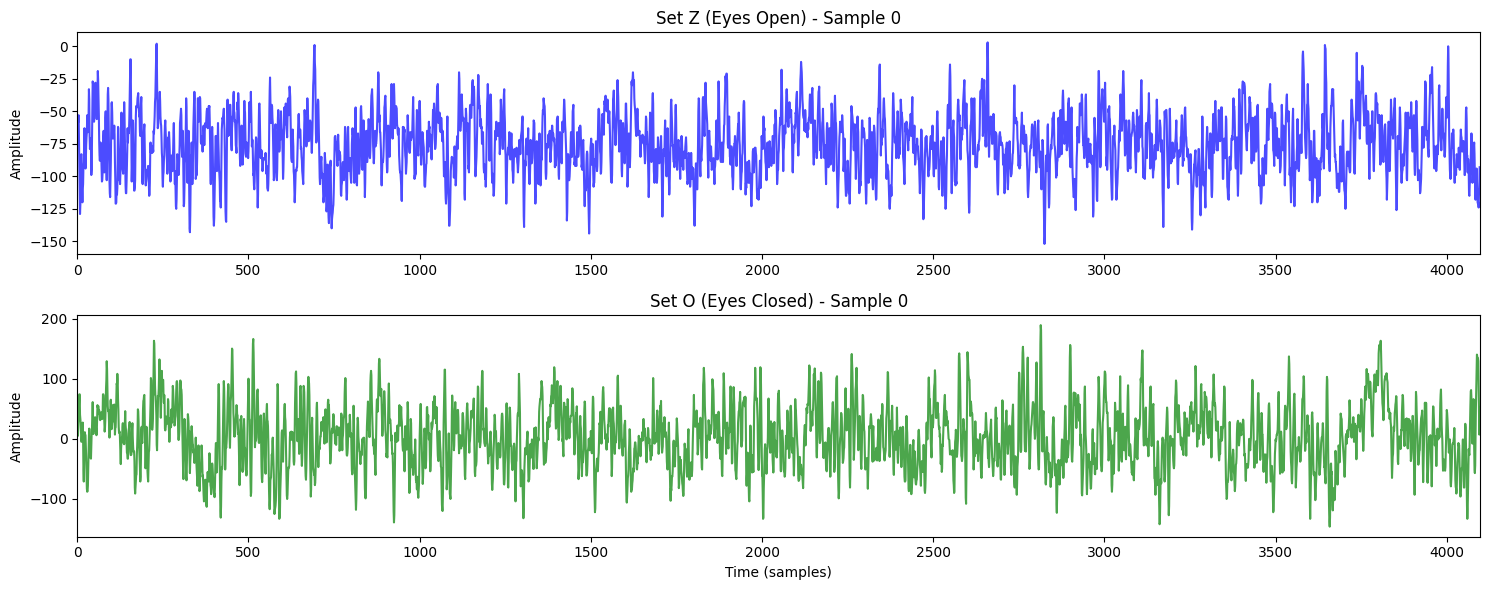

In [6]:
plt.figure(figsize=(15, 6))

plt.subplot(2, 1, 1)
plt.plot(Z_data[0], color='blue', alpha=0.7)
plt.title('Set Z (Eyes Open) - Sample 0')
plt.xlim(0, 4097)
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
plt.plot(O_data[0], color='green', alpha=0.7)
plt.title('Set O (Eyes Closed) - Sample 0')
plt.xlim(0, 4097)
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()

## 2. Statistical Analysis
Comparing Mean, Standard Deviation, and Total Power.

/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_35183/3806586631.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Z (Open)', 'O (Closed)'])
/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_35183/3806586631.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Z (Open)', 'O (Closed)'])
/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_35183/3806586631.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['Z (Open)', 'O (Closed)'])


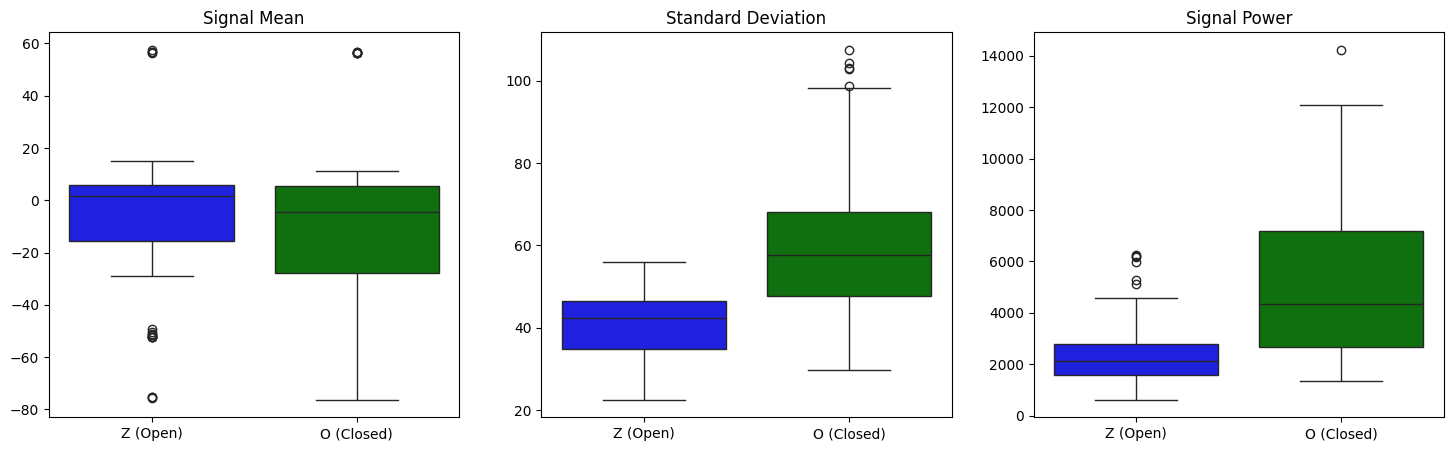

In [7]:
# Calculate stats
z_mean = np.mean(Z_data, axis=1)
z_std = np.std(Z_data, axis=1)
z_power = np.sum(Z_data**2, axis=1) / Z_data.shape[1]

o_mean = np.mean(O_data, axis=1)
o_std = np.std(O_data, axis=1)
o_power = np.sum(O_data**2, axis=1) / O_data.shape[1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Mean
sns.boxplot(data=[z_mean, o_mean], ax=axes[0], palette=['blue', 'green'])
axes[0].set_xticklabels(['Z (Open)', 'O (Closed)'])
axes[0].set_title('Signal Mean')

# Std
sns.boxplot(data=[z_std, o_std], ax=axes[1], palette=['blue', 'green'])
axes[1].set_xticklabels(['Z (Open)', 'O (Closed)'])
axes[1].set_title('Standard Deviation')

# Power
sns.boxplot(data=[z_power, o_power], ax=axes[2], palette=['blue', 'green'])
axes[2].set_xticklabels(['Z (Open)', 'O (Closed)'])
axes[2].set_title('Signal Power')

plt.show()

## 3. Spectral Analysis (Alpha Rhythm)
Alpha waves (8-12 Hz) are prominent when eyes are closed and suppressed when eyes are open (Alpha Blocking).
We expect to see a clear peak around 10Hz for **Set O**, but not for **Set Z**.

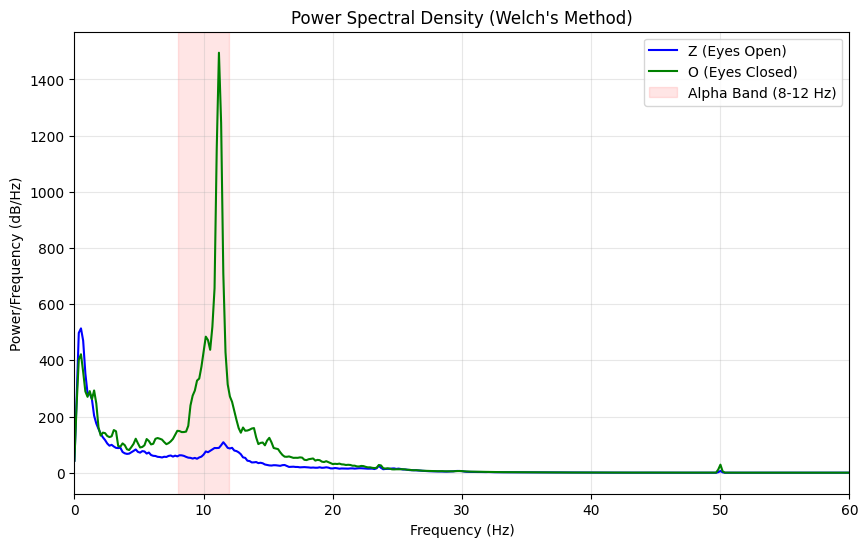

In [8]:
def get_psd_averaged(data, fs):
    psds = []
    for signal in data:
        freqs, psd = welch(signal, fs, nperseg=1024)
        psds.append(psd)
    return freqs, np.mean(psds, axis=0)

freqs_z, psd_z = get_psd_averaged(Z_data, fs)
freqs_o, psd_o = get_psd_averaged(O_data, fs)

plt.figure(figsize=(10, 6))
plt.plot(freqs_z, psd_z, label='Z (Eyes Open)', color='blue')
plt.plot(freqs_o, psd_o, label='O (Eyes Closed)', color='green')

plt.title('Power Spectral Density (Welch\'s Method)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power/Frequency (dB/Hz)')
plt.xlim(0, 60)

# Highlight Alpha Range
plt.axvspan(8, 12, color='red', alpha=0.1, label='Alpha Band (8-12 Hz)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Conclusion
1. **Alpha Peak**: Observe if Set O shows a significantly higher peak in the 8-12 Hz range compared to Set Z.
2. **Variability**: While spectral properties differ due to visual processing/idling, both signals represent a **healthy brain state** without epileptiform activity (spikes/sharp waves).
3. **Justification for Merging**: 
   - For the purpose of **seizure detection**, both Z and O are considered 'Negative' samples.
   - Including both variations makes the model more robust to natural EEG fluctuations (eyes open/closed) that might occur during long-term monitoring.
   - Merging them into class '0' is methodologically sound.